# Fellowship of the Ring

Fitz Koch  
2026-04-15

# Setup

In [2]:
import sys, os
from pathlib import Path

_project_root = Path.cwd()
while not (_project_root / "src").exists():
    _project_root = _project_root.parent
os.chdir(_project_root)

In [3]:
from pathlib import Path
import random
from itertools import product

import srt
import pandas as pd
import chardet
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  

from src.hedonometer import parse_text, import_hedonometer_as_dict

In [4]:
# constants
plt.style.use(["ggplot"])
IMG_WIDTH = 12
sns.set_palette("muted")

## Variables

In [5]:
srt_file = Path(
    "Data/subtitles/Fellowship Of The Ring 2001 [Extended Edition] SDH-en.srt"
)
trope_file = Path("Data/trope_time_series/Fellowship_of_the_Ring_filled_copy.csv")
movie_title = "FoTR"
top_genres = ["Action", "Adventure", "Fantasy"]

# srt_file = Path("Data/subtitles/Clueless.1995.srt")
# trope_file = Path("Data/trope_time_series/clueless_tropes.csv")
# movie_title = "Clueless"

# Design

1.  Wrangle data sources:
    -   subtitle file
    -   time-tagged trope file
2.  Run hedonometer on subtitles, tropes, and the two together
3.  Calculate genre expectation for each.

# Wrangling

## Subtitle File

First we load in the subtitle file and clean up the delta columns. To do so we need a custom parser that works on our two formats (ugh). That’s a claude job, I’m sorry.

In [6]:
def parse_timestamp(t):
    if pd.isna(t):
        return np.nan
    # already a timedelta
    if hasattr(t, "total_seconds"):
        return t.total_seconds()
    t = str(t).strip()
    if ":" in t:
        parts = [int(p) for p in t.split(":")]
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    if "." in t:
        parts = [int(p) for p in t.split(".")]
        if len(parts) == 3:
            return parts[0] * 3600 + parts[1] * 60 + parts[2]
        elif len(parts) == 2:
            return parts[0] * 60 + parts[1]
    try:
        return float(t)
    except Exception as e:
        print(f"Due to {e}, casting {t} to nan")
        return np.nan

Now we can start going

In [7]:
with open(srt_file, "r") as f:
    subtitle_generator = srt.parse(f.read())
subtitles = list(subtitle_generator)
subtitle_df = pd.DataFrame(
    [{"start": s.start, "end": s.end, "content": s.content} for s in subtitles]
)
subtitle_df["start"] = subtitle_df["start"].apply(parse_timestamp)
subtitle_df["end"] = subtitle_df["end"].apply(parse_timestamp)
subtitle_df = subtitle_df.sort_values(by="start", ascending=True)
subtitle_df.head()

Do some light html NLP, then parse the text with our standard tokenizer.

In [8]:
subtitle_df["content"] = subtitle_df["content"].str.replace("\n", " ")
subtitle_df["content"] = subtitle_df["content"].str.replace("<i>", " ")
subtitle_df["content"] = subtitle_df["content"].str.replace("</i>", " ")
subtitle_df["content"] = subtitle_df["content"].apply(parse_text)

Add a wordcount column:

In [9]:
subtitle_df["wordcount"] = subtitle_df["content"].str.len()
subtitle_df.head()

## Trope File

Similarly convert the time deltas into seconds for the trope file.

In [10]:
with open(trope_file, "rb") as f:
    encoding = chardet.detect(f.read())["encoding"]
trope_df = pd.read_csv(trope_file, encoding=encoding)
trope_df["start"] = trope_df["Start Time"].apply(parse_timestamp)
trope_df["end"] = trope_df["End Time"].apply(parse_timestamp)
trope_df["Camel Trope"] =  trope_df['Trope'].str.replace(" ", "") 
trope_df.head()

Due to could not convert string to float: 'end of film?', casting end of film? to nan

Similarly, add a parse into tokens and add wordcount.

In [11]:
trope_df["Description"] = trope_df["Description"].apply(parse_text)
trope_df["wordcount"] = trope_df["Description"].str.len()
trope_df["wordcount"].sum()

np.float64(17664.0)

# Hedonometer

## Basics

Now we run the Hedonometer, per Dodds et al. (2011) and especially Dodds et al. (2015). The standard logic is fairly simple:

1.  Sliding window of $N$ words, where they used $N = 10,000$
2.  Exclude words with score $h \in [5-\delta, 5+\delta]$ to yield a lens $L$
3.  That gives the results for each window of $N$ words and we slide that across the series.

$$
h_{\text{avg}}T = \frac{\sum_{w \in L} f_w h_{\text{avg}} (w)}{ \sum_{w \in L} f_w}
$$

## Decision Points

The question is: what size window do we want to have, and how do we want to assign it? The purpose of the window is to average out the happiness of the text as we read it, but it doesn’t really make sense in movies for the ‘experience’ of the text to be over a certain period of time.

A very academic [virtual speech website](https://learn.virtualspeech.com/tools/convert-words-to-time/) claims that it takes 10 minutes to read 1300 words aloud. Other sources say that people read at about 250 wpm, and so take roughly 4 minutes to read 1000 words. So we have a few options:

1.  Make our window a parameterized $N / 1000 * 4$ minutes long, and just take whatever words we get
2.  Categorize the movie by scene (more work).
3.  Stick to old reliable: just use how ever many tropes we need to get over $N$ words.

We’ll go with option 1 for now, as I think art is experience as a relation with time.

### Faulty Reasoning

We have another decision point: how to we deal with the over-counting of tropes from our methodology above, where tropes are “on” for all the moments in the subtitle file that they are present for? To reduce this over counting, one option is to scale their frequency by some value $\alpha < 1$, so that we have:

$$
h_{\text{avg}}T = \frac{\sum_{w \in L_{s}} \alpha f_w h_{\text{avg}} (w) + \alpha \sum_{w \in L_{t}}  f_w h_{\text{avg}} (w)}{ \sum_{w \in L_{s}} f_{w} + \alpha \sum_{w \in L_{t} } f_{w}}
$$

### Fixed Reasoning

It probably makes more sense to just say we only use one trope once per window that it applies in by building this within the window, which will take more compute but is okay. We can keep $\alpha$, however, as a sort of “cultural commentary rate.”

## Logic

We want to slide a happiness_assignation window over a certain time period. We want to take the start and end time of the movie, grab all the tropes and subtitles that fit in there, and return their happiness.

First, a definition to turn data into happiness scores.

In [12]:
def assign_happiness(data, lens_size, labmt: dict )-> np.ndarray:
    happiness_scores = np.array([labmt.get(word, np.nan) for word in data])
    happiness_scores = np.where(
        (happiness_scores < 5 - lens_size) | (happiness_scores > 5 + lens_size),
        happiness_scores,
        np.nan,
    )
    return happiness_scores

Second, a function to apply happiness to subtitle and trope content over a sliding window of time, and return the results

In [13]:
def sliding_window_scores(
    window_start,
    window_end,
    lens_size,
    labmt,
    subs: pd.DataFrame,
    tropes: pd.DataFrame,
):
    sub_tokens = []
    for _, row in subs.iterrows():
        if window_start <= row["start"] < window_end and isinstance(
            row["content"], list
        ):
            sub_tokens += row["content"]

    seen_tropes = set()
    trope_tokens = []
    for _, row in tropes.iterrows():
        key = (row["start"], row["end"])
        if (
            key not in seen_tropes
            and row["start"] < window_end
            and row["end"] > window_start
        ):
            trope_tokens += row["Description"]
            seen_tropes.add(key)

    sub_hs = assign_happiness(sub_tokens, lens_size, labmt)
    trope_hs = assign_happiness(trope_tokens, lens_size, labmt)
    return sub_hs, trope_hs

Third, a function to turn the scores into the proper hedonometer result, as required:

In [14]:
def aggregate_scores(sub_hs, trope_hs, alpha):
    sub_score = np.nan if np.all(np.isnan(sub_hs)) else np.nanmean(sub_hs)
    trope_score = np.nan if np.all(np.isnan(trope_hs)) else np.nanmean(trope_hs)

    num = np.nansum(sub_hs) + alpha * np.nansum(trope_hs)
    den = np.sum(~np.isnan(sub_hs)) + alpha * np.sum(~np.isnan(trope_hs))
    comb_score = num / den if den > 0 else np.nan
    return sub_score, trope_score, comb_score

Fourth, a wrapper function to do them all:

In [15]:
def hedonometer_score(subs, tropes, lens_size, alpha, step_size=30):
    labmt = import_hedonometer_as_dict()
    end_time = max(subs["end"].max(), tropes["end"].max())
    results = []
    for start in np.arange(0, end_time, step_size):
        end = start + 4 * 60
        sub_hs, trope_hs = sliding_window_scores(
            start, end, lens_size, labmt, subs, tropes
        )
        sub_score, trope_score, comb_score = aggregate_scores(sub_hs, trope_hs, alpha)
        results.append(
            {
                "start": start,
                "end": end,
                "Subtitle": sub_score,
                "Trope": trope_score,
                "Combined": comb_score,
            }
        )
    return pd.DataFrame(results)

Finally, a function that visualizes the results on an axis:

In [16]:
def plot_hedonometer(subs, tropes, lens_size, alpha, movie, ax=None):
    if not ax:
        _, ax = plt.subplots(figsize=(12, IMG_WIDTH))

    df = hedonometer_score(subs, tropes, lens_size, alpha, step_size=30)
    melted = df.melt(
        id_vars="start",
        value_vars=["Subtitle", "Trope", "Combined"],
        var_name="series",
        value_name="happiness",
    )
    sns.lineplot(
        data=melted,
        x="start",
        y="happiness",
        hue="series",
        ax=ax,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Happiness")
    ax.set_title(
        rf"Average Happiness Over Time for {movie} with lens=${lens_size}, \alpha={alpha}$"
    )

A quick grid search:

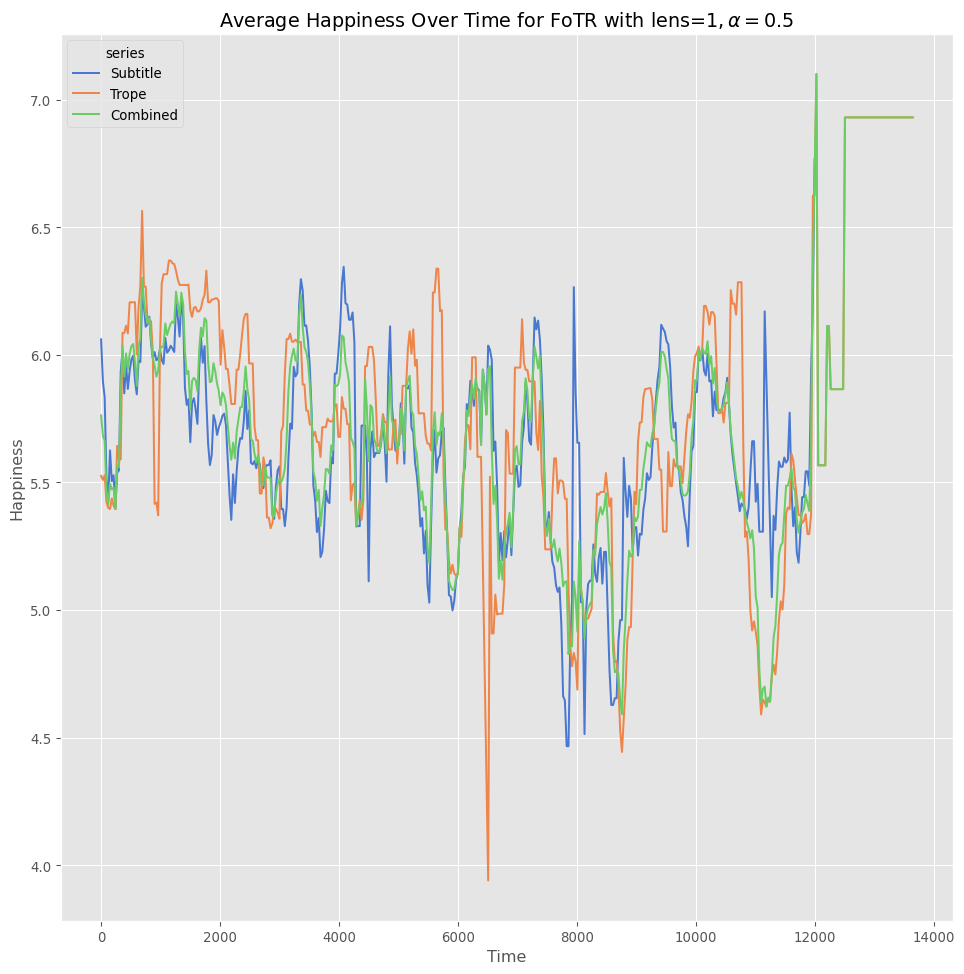

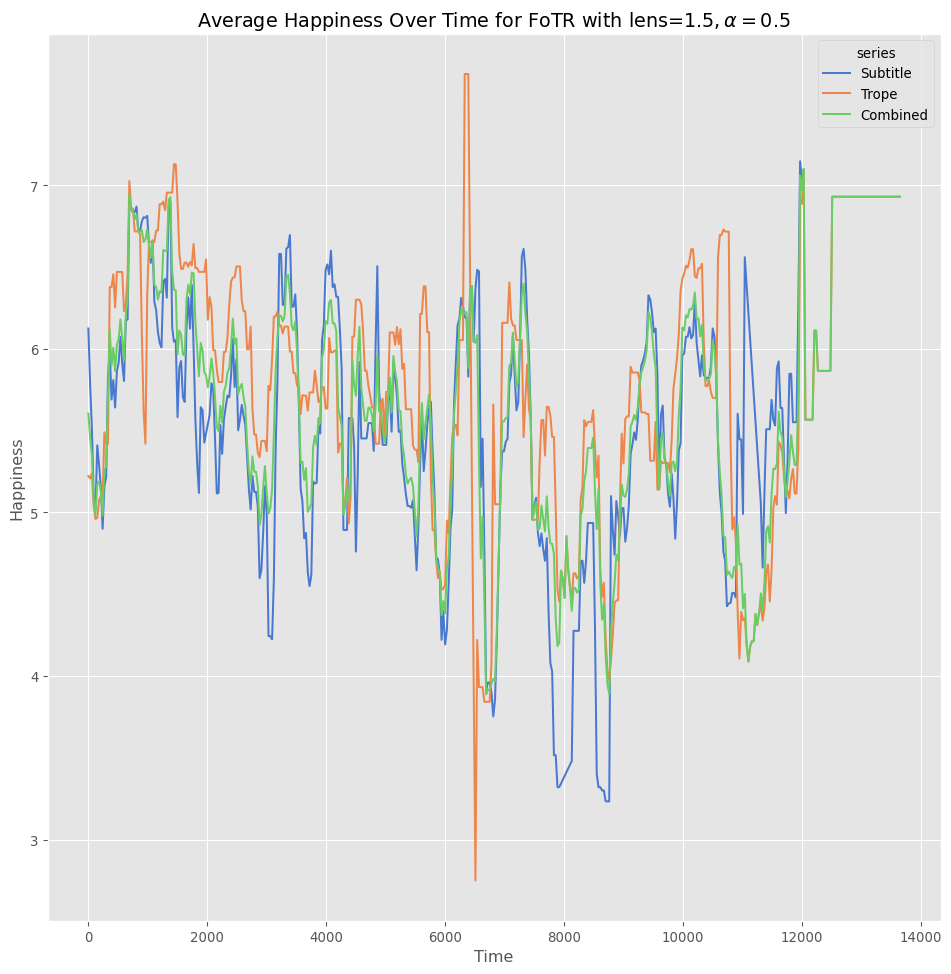

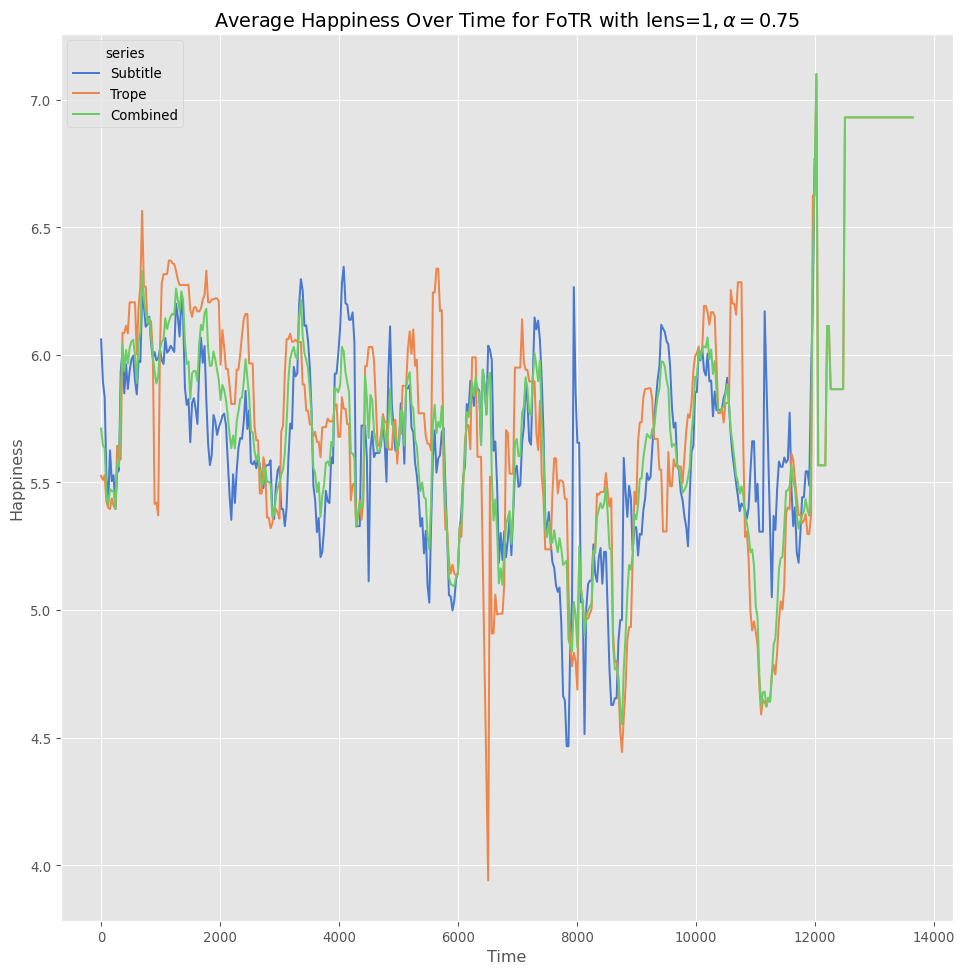

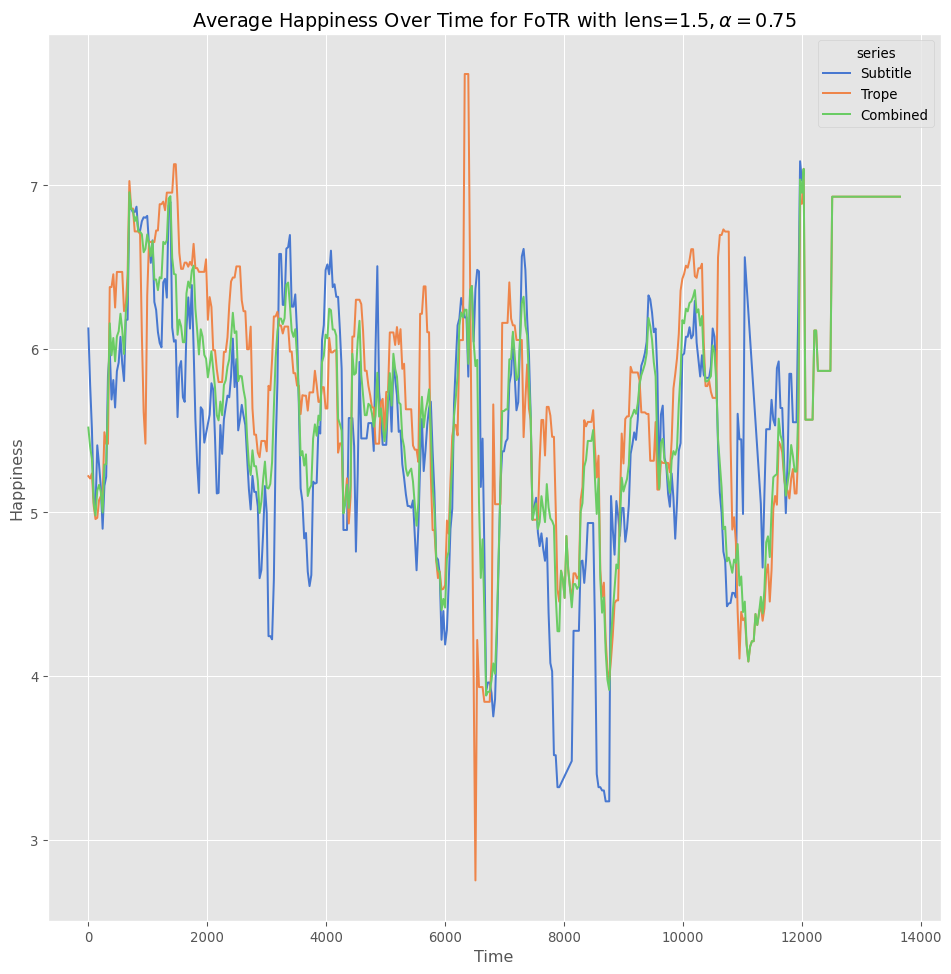

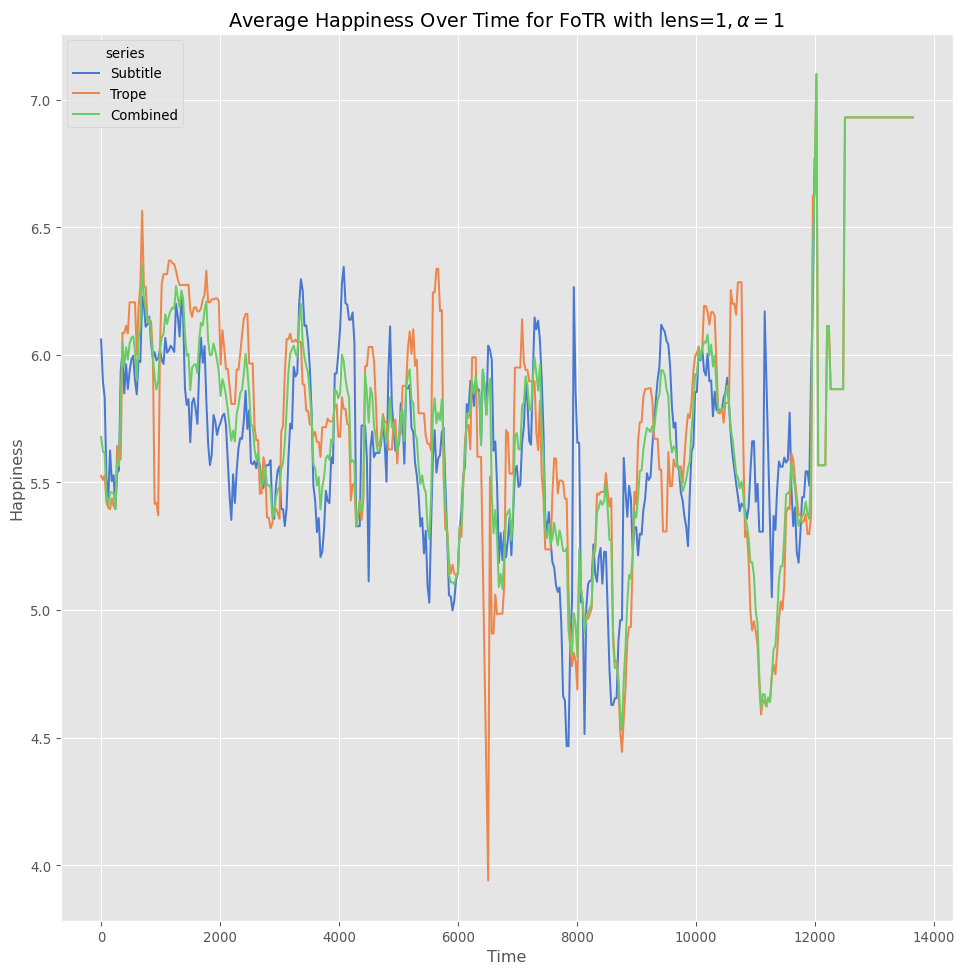

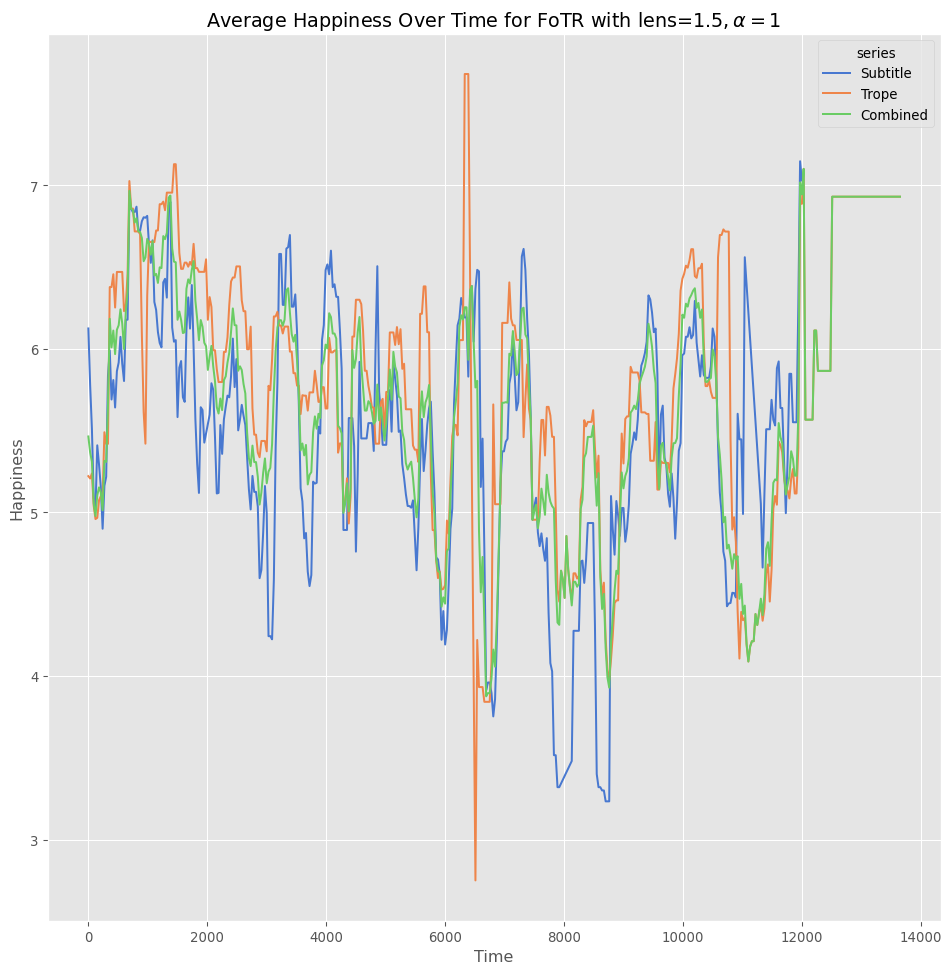

In [17]:
alphas = [0.5, 0.75, 1]
lens_sizes = [1, 1.5]

for alpha, lens_size in product(alphas, lens_sizes):
    plot_hedonometer(subtitle_df, trope_df, lens_size, alpha, movie_title)

# Genre

Now we want to plot the of the genre, as calculated from the tf-idf matrix. This is stuff we already did in the old repository, but if we represent the data as a series of **events** actually makes it faster. Sort of like a Gillepsie simulation.

First we need to build a combined dataframe with all events. Basically, we’ll put active tropes on every line where they overlap with the subtitle, and put unplaced tropes on their own lines.

In [18]:
def combine_frames(subs: pd.DataFrame, tropes: pd.DataFrame):
    combined = subs.copy(deep=True)
    n_rows = subs.shape[0]
    combined["active tropes"] = [[] for _ in range(n_rows)]
    combined["trope content"] = [[] for _ in range(n_rows)]

    unplaced = []

    for _, trow in tropes.iterrows():
        placed = False
        for idx, srow in subs.iterrows():
            if trow.start < srow.end and trow.end > srow.start:
                placed = True
                combined.at[idx, "active tropes"] += [trow["Camel Trope"]]
                combined.at[idx, "trope content"] += trow["Description"]
        if not placed:
            unplaced.append({
                "start": trow.start,
                "end": trow.end,
                "content": [],
                "active tropes": [trow["Trope"]],
                "trope content": trow["Description"],
            })

    full = pd.concat([combined, pd.DataFrame(unplaced)], ignore_index=True)
    return full.sort_values("start").reset_index(drop=True)   

Now we need to build the tf_idf:

In [19]:
def build_tf_idf_matrix(min_movies=5):
    df = pd.read_csv("Data/2020_genre_counts_by_trope.csv")
    genres = df.columns[2:29].tolist()
    num_genres = len(genres)

    # drop tropes too sparse to give reliable genre signal
    df = df[df['Number_movies'] >= min_movies].copy()

    df_tropes = df[genres]  # original counts, used for IDF

    # smoothed IDF: log((1 + N) / (1 + df_t)) + 1
    # prevents single-genre tropes from getting IDF = log(27) ~ 3.3 and dominating everything
    df['idf'] = np.log((1 + num_genres) / (1 + (df_tropes > 0).sum(axis=1))) + 1

    # TF: fraction of this trope's genre signal pointing at each genre
    row_sums = df[genres].sum(axis=1)
    df[genres] = df[genres].divide(row_sums.where(row_sums > 0, 1), axis=0)

    # combine
    df[genres] = df[genres].multiply(df['idf'], axis=0)
    df.drop(columns=['idf'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df['Trope'] = df['Trope'].str.strip()
    df = df[['Trope'] + genres]
    df.dropna(how='all', inplace=True)
    df.set_index("Trope", inplace=True)
    df.to_csv("Data/Cleaned-tf_idf-matrix.csv")
    return df 

tf_idf = build_tf_idf_matrix()
tf_idf.head()

5 rows × 27 columns

Now we need a function for evaluating the scores for a genre:

In [20]:
def assign_generic_scores(tropes, tf_idf):
    if not tropes:
        return {g: 0.0 for g in tf_idf.columns}
    valid = [t for t in tropes if t in tf_idf.index]
    raw = tf_idf.loc[valid].sum()
    total = raw.sum()
    return (raw / total if total > 0 else raw).to_dict()

Finally we want to apply the above to every event.

In [21]:
def build_genre_columns(combined, tf_idf):
    scores = combined['active tropes'].apply(lambda tropes: assign_generic_scores(tropes, tf_idf))
    return pd.concat([combined[['start', 'end', 'active tropes']], pd.DataFrame(scores.tolist(), index=combined.index)], axis =1)

Lets check and see that this looks reasonable:

In [22]:
combined = combine_frames(subtitle_df, trope_df)
combined = build_genre_columns(combined , tf_idf)
combined.head(20)

20 rows × 30 columns

Plot to see how it looks over time

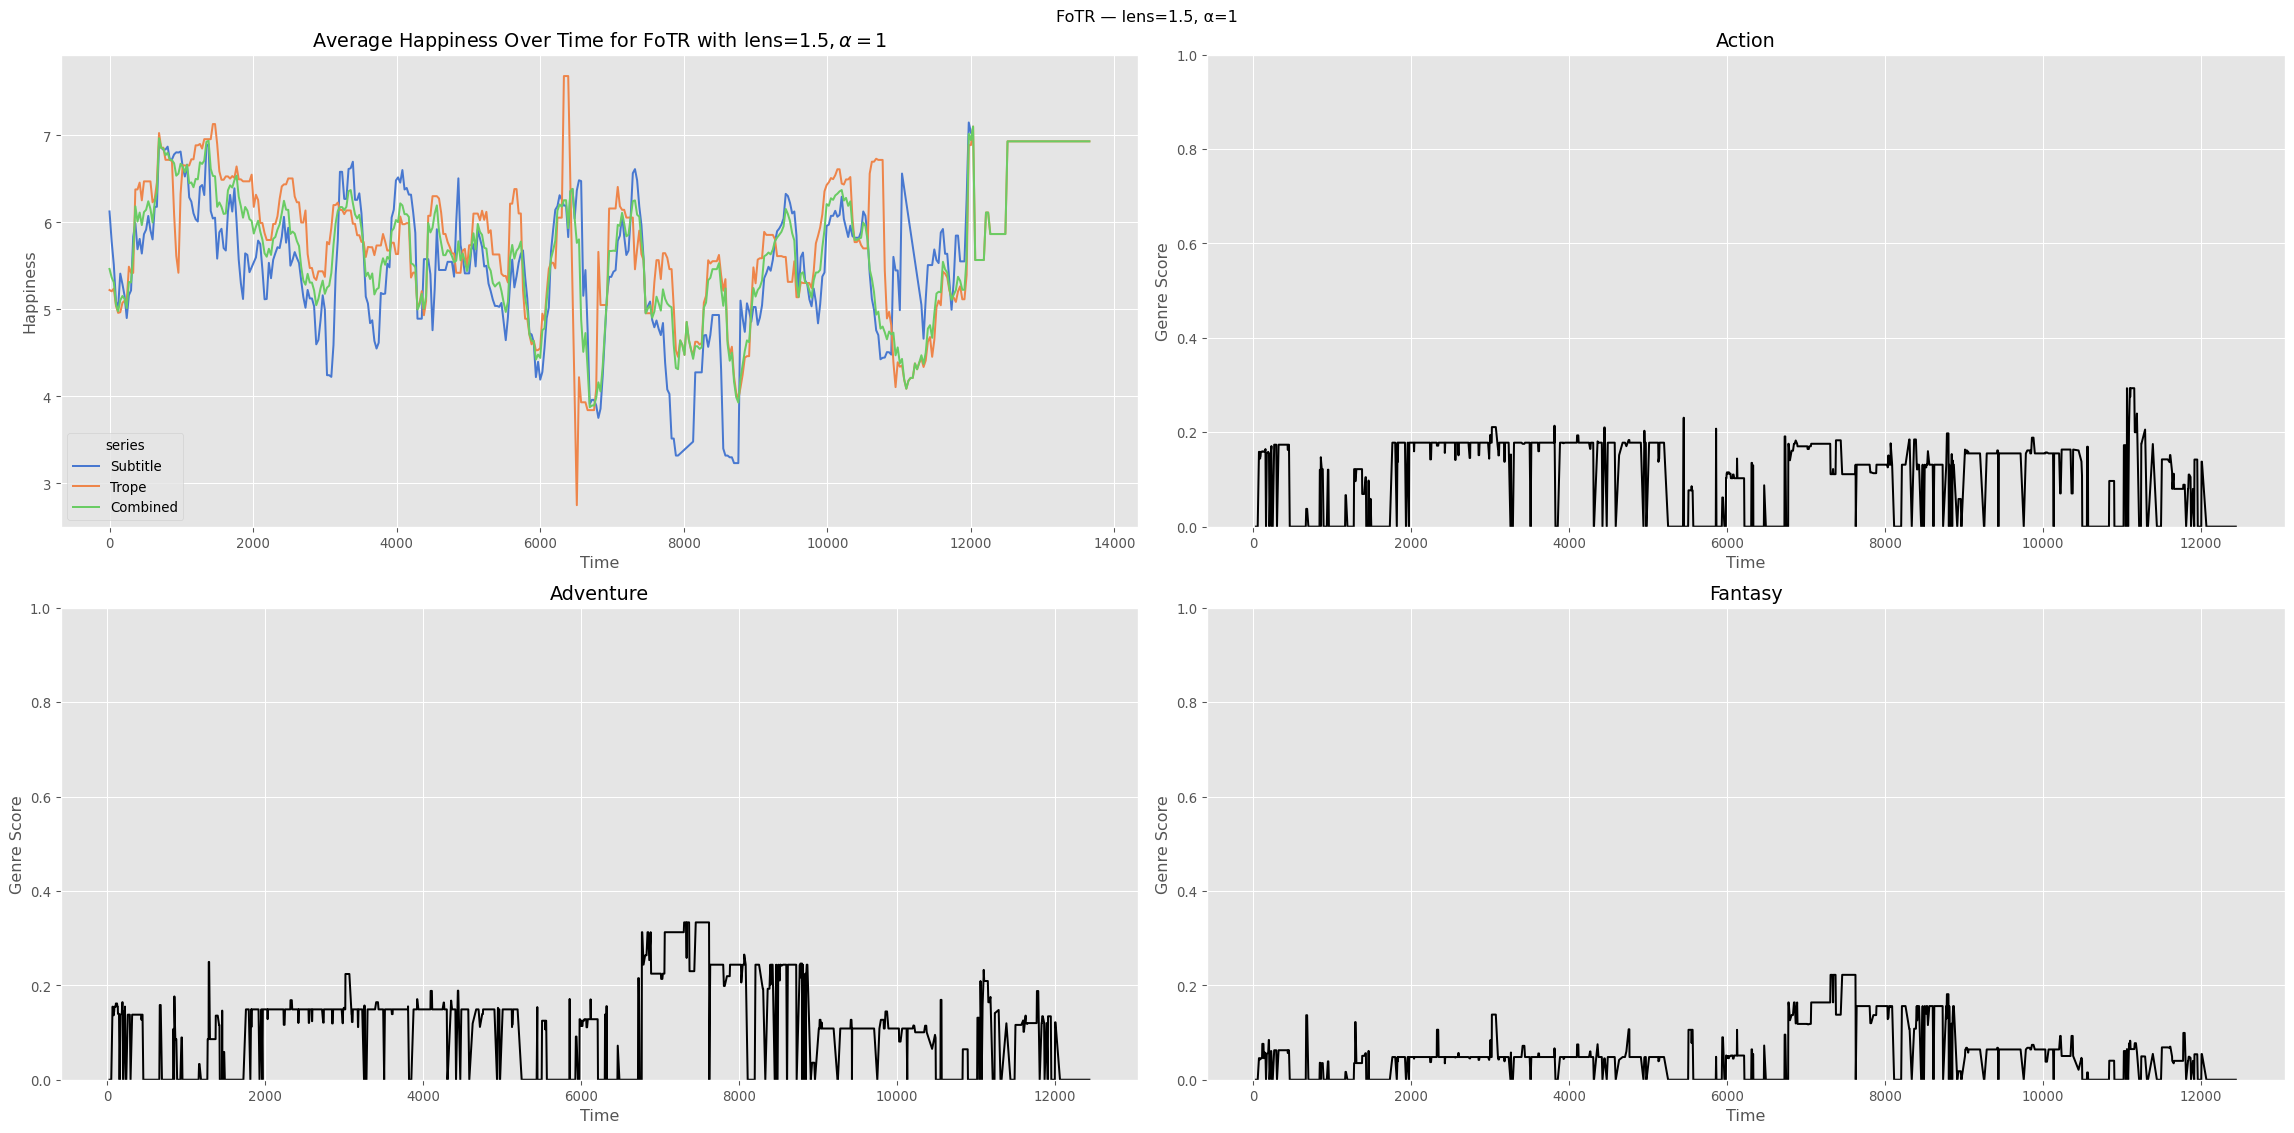

In [23]:
def plot_all(subs, tropes, lens_size, alpha, movie, top_genres, tf_idf):
    fig, axes = plt.subplots(2, 2, figsize=(IMG_WIDTH * 2, IMG_WIDTH))
    fig.suptitle(f"{movie} — lens={lens_size}, α={alpha}")

    plot_hedonometer(subs, tropes, lens_size, alpha, movie, ax=axes[0, 0])
    combined = combine_frames(subs, tropes)
    genre_df = build_genre_columns(combined, tf_idf)

    for ax, genre in zip(axes.flat[1:], top_genres):
        sns.lineplot(data=genre_df, x="start", y=genre, ax=ax, color="black")
        ax.set_title(genre)
        ax.set_xlabel("Time")
        ax.set_ylabel("Genre Score")
        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


plot_all(
    subtitle_df,
    trope_df,
    lens_size=1.5,
    alpha=1,
    movie=movie_title,
    top_genres=top_genres,
    tf_idf=tf_idf,
)

Dodds, Peter Sheridan, Eric M. Clark, Suma Desu, Morgan R. Frank, Andrew J. Reagan, Jake Ryland Williams, Lewis Mitchell, et al. 2015. “Human Language Reveals a Universal Positivity Bias.” *Proceedings of the National Academy of Sciences* 112 (8): 2389–94. <https://doi.org/10.1073/pnas.1411678112>.

Dodds, Peter Sheridan, Kameron Decker Harris, Isabel M. Kloumann, Catherine A. Bliss, and Christopher M. Danforth. 2011. “Temporal Patterns of Happiness and Information in a Global Social Network: Hedonometrics and Twitter.” *PLOS ONE* 6 (12): e26752. <https://doi.org/10.1371/journal.pone.0026752>.